# Surface Code Memory Experiment

Generates Guppy source code for rotated surface codes using `pecos.guppy.surface`,
then compiles to HUGR and runs with selene-sim using the Stim simulator backend.

In [1]:
from pecos.compilation_pipeline import compile_guppy_to_hugr
from pecos.guppy.surface import generate_surface_code_module, get_num_qubits, make_surface_code
from selene_sim import IdealErrorModel, SimpleRuntime, Stim, build

In [2]:
NUM_ROUNDS = 3
NUM_SHOTS = 10
BASIS = "Z"

## Distance 3

/tmp/ipykernel_2487889/2697175300.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


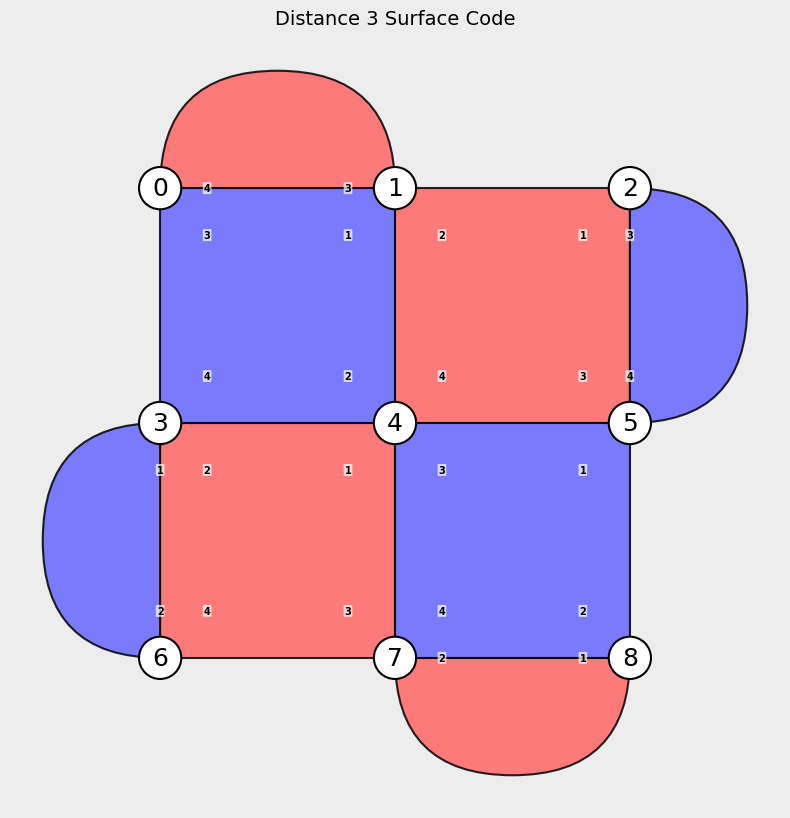

In [3]:
from pecos.qec.surface import plot_surface_code

fig, ax = plot_surface_code(3, show_cnot_order=True)
ax.set_title("Distance 3 Surface Code", fontsize=14, pad=10)
fig.show()

In [4]:
distance = 3
source = generate_surface_code_module(distance)
print(source)

"""Surface code patch (dx=3, dz=3) implementation in Guppy.

Auto-generated from SurfacePatch geometry.

Data qubits: 9
X stabilizers: 4
Z stabilizers: 4
Ancilla qubits: 8 (one per stabilizer)
"""

from guppylang import guppy
from guppylang.std.builtins import array, owned, result
from guppylang.std.quantum import cx, discard, h, measure, measure_array, qubit, x


@guppy.struct
class SurfaceCode_3x3:
    """Surface code patch with dx=3, dz=3 (9 data qubits)."""

    data: array[qubit, 9]


@guppy.struct
class Syndrome_3x3:
    """Syndrome for dx=3, dz=3 patch."""

    synx: array[bool, 4]
    synz: array[bool, 4]


# === State Preparation ===

@guppy
def prep_z_basis() -> SurfaceCode_3x3:
    """Prepare logical |0_L> state."""
    data = array(qubit() for _ in range(9))
    return SurfaceCode_3x3(data)


@guppy
def prep_x_basis() -> SurfaceCode_3x3:
    """Prepare logical |+_L> state."""
    data = array(qubit() for _ in range(9))
    for i in range(9):
        h(data[i])
    return Su

In [5]:
num_data = distance * distance
num_stab = (num_data - 1) // 2
num_qubits = get_num_qubits(distance)
print(f"Patch: dx={distance}, dz={distance}")
print(f"Data qubits: {num_data}, X stabilizers: {num_stab}, Z stabilizers: {num_stab}")
print(f"Total qubits (data + ancilla): {num_qubits}")

prog = make_surface_code(distance=distance, num_rounds=NUM_ROUNDS, basis=BASIS)
hugr_bytes = compile_guppy_to_hugr(prog)
print(f"HUGR size: {len(hugr_bytes)} bytes")

instance = build(hugr_bytes, name=f"surface_d{distance}")
print("Built selene instance.")

Patch: dx=3, dz=3
Data qubits: 9, X stabilizers: 4, Z stabilizers: 4
Total qubits (data + ancilla): 17


HUGR size: 299844 bytes


Built selene instance.


In [6]:
for shot_idx, shot_results in enumerate(
    instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=NUM_SHOTS,
        error_model=IdealErrorModel(),
        runtime=SimpleRuntime(),
        n_processes=1,
    ),
):
    results = list(shot_results)
    if shot_idx < 3:
        print(f"Shot {shot_idx}:")
        for name, values in results:
            print(f"  {name}: {values}")
    elif shot_idx == 3:
        print(f"... ({NUM_SHOTS - 3} more shots omitted)")

Shot 0:
  synx: [0, 1, 1, 0]
  synz: [0, 0, 0, 0]
  synx: [0, 1, 1, 0]
  synz: [0, 0, 0, 0]
  synx: [0, 1, 1, 0]
  synz: [0, 0, 0, 0]
  final: [0, 1, 1, 1, 0, 1, 1, 0, 1]
Shot 1:
  synx: [0, 0, 1, 1]
  synz: [0, 0, 0, 0]
  synx: [0, 0, 1, 1]
  synz: [0, 0, 0, 0]
  synx: [0, 0, 1, 1]
  synz: [0, 0, 0, 0]
  final: [1, 1, 0, 0, 0, 0, 0, 0, 0]
Shot 2:
  synx: [1, 1, 1, 1]
  synz: [0, 0, 0, 0]
  synx: [1, 1, 1, 1]
  synz: [0, 0, 0, 0]
  synx: [1, 1, 1, 1]
  synz: [0, 0, 0, 0]
  final: [1, 1, 0, 0, 0, 0, 0, 0, 0]
... (7 more shots omitted)


## Distance 5

/tmp/ipykernel_2487889/2277946867.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


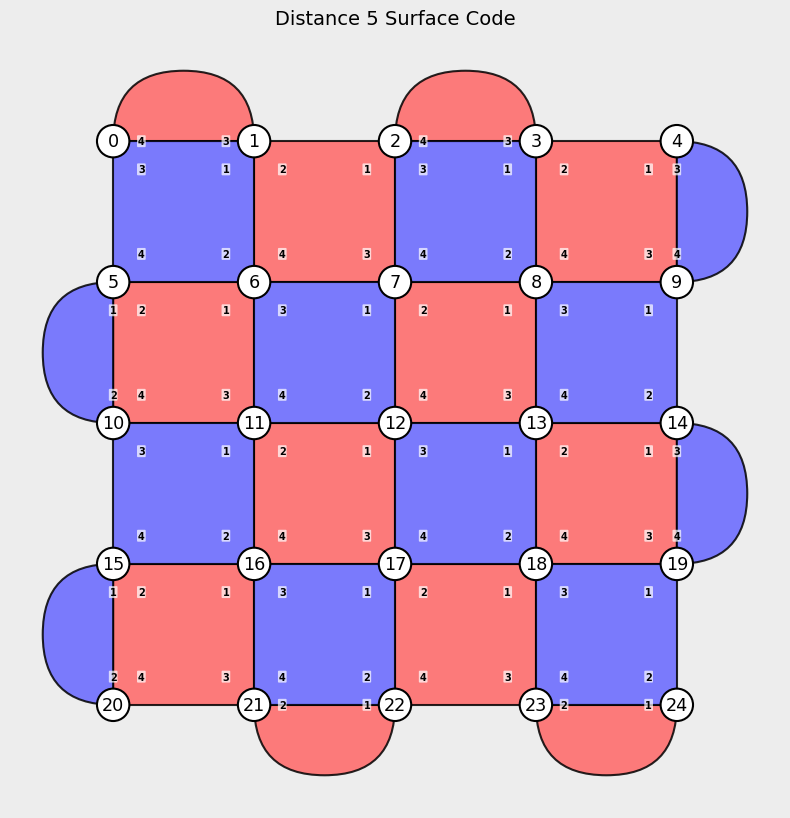

In [7]:
fig, ax = plot_surface_code(5, show_cnot_order=True)
ax.set_title("Distance 5 Surface Code", fontsize=14, pad=10)
fig.show()

In [8]:
distance = 5
source = generate_surface_code_module(distance)
print(source)

"""Surface code patch (dx=5, dz=5) implementation in Guppy.

Auto-generated from SurfacePatch geometry.

Data qubits: 25
X stabilizers: 12
Z stabilizers: 12
Ancilla qubits: 24 (one per stabilizer)
"""

from guppylang import guppy
from guppylang.std.builtins import array, owned, result
from guppylang.std.quantum import cx, discard, h, measure, measure_array, qubit, x


@guppy.struct
class SurfaceCode_5x5:
    """Surface code patch with dx=5, dz=5 (25 data qubits)."""

    data: array[qubit, 25]


@guppy.struct
class Syndrome_5x5:
    """Syndrome for dx=5, dz=5 patch."""

    synx: array[bool, 12]
    synz: array[bool, 12]


# === State Preparation ===

@guppy
def prep_z_basis() -> SurfaceCode_5x5:
    """Prepare logical |0_L> state."""
    data = array(qubit() for _ in range(25))
    return SurfaceCode_5x5(data)


@guppy
def prep_x_basis() -> SurfaceCode_5x5:
    """Prepare logical |+_L> state."""
    data = array(qubit() for _ in range(25))
    for i in range(25):
        h(data[i])
  

In [9]:
num_data = distance * distance
num_stab = (num_data - 1) // 2
num_qubits = get_num_qubits(distance)
print(f"Patch: dx={distance}, dz={distance}")
print(f"Data qubits: {num_data}, X stabilizers: {num_stab}, Z stabilizers: {num_stab}")
print(f"Total qubits (data + ancilla): {num_qubits}")

prog = make_surface_code(distance=distance, num_rounds=NUM_ROUNDS, basis=BASIS)
hugr_bytes = compile_guppy_to_hugr(prog)
print(f"HUGR size: {len(hugr_bytes)} bytes")

instance = build(hugr_bytes, name=f"surface_d{distance}")
print("Built selene instance.")

Patch: dx=5, dz=5
Data qubits: 25, X stabilizers: 12, Z stabilizers: 12
Total qubits (data + ancilla): 49


HUGR size: 465780 bytes


Built selene instance.


In [10]:
for shot_idx, shot_results in enumerate(
    instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=NUM_SHOTS,
        error_model=IdealErrorModel(),
        runtime=SimpleRuntime(),
        n_processes=1,
    ),
):
    results = list(shot_results)
    if shot_idx < 3:
        print(f"Shot {shot_idx}:")
        for name, values in results:
            print(f"  {name}: {values}")
    elif shot_idx == 3:
        print(f"... ({NUM_SHOTS - 3} more shots omitted)")

Shot 0:
  synx: [0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  final: [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0]
Shot 1:
  synx: [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  final: [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0]
Shot 2:
  synx: [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## Distance 7

/tmp/ipykernel_2487889/1787852394.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


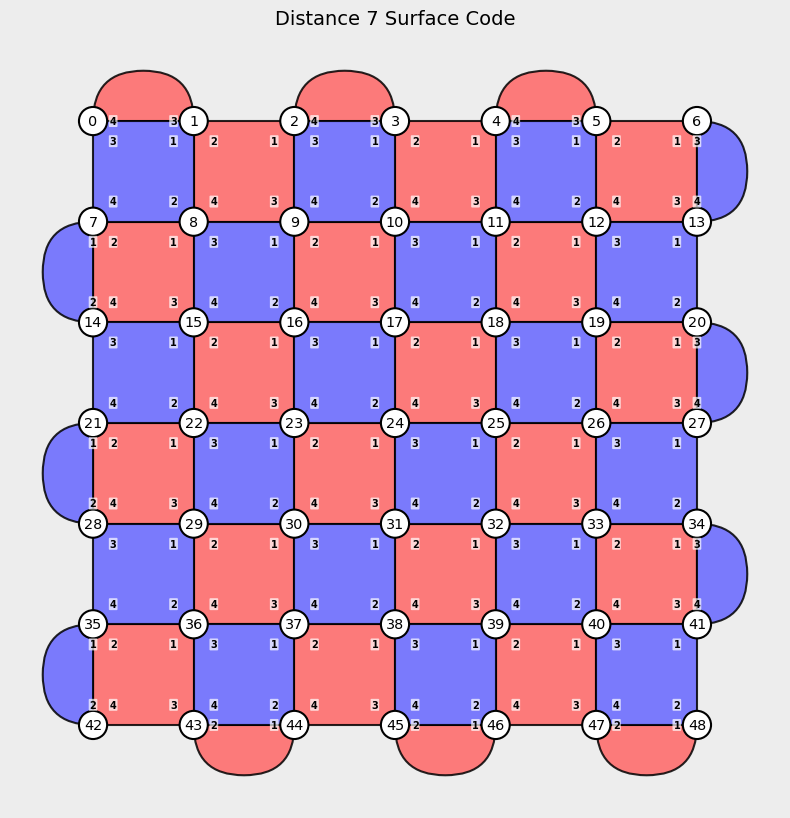

In [11]:
fig, ax = plot_surface_code(7, show_cnot_order=True)
ax.set_title("Distance 7 Surface Code", fontsize=14, pad=10)
fig.show()

In [12]:
distance = 7
source = generate_surface_code_module(distance)
print(source)

"""Surface code patch (dx=7, dz=7) implementation in Guppy.

Auto-generated from SurfacePatch geometry.

Data qubits: 49
X stabilizers: 24
Z stabilizers: 24
Ancilla qubits: 48 (one per stabilizer)
"""

from guppylang import guppy
from guppylang.std.builtins import array, owned, result
from guppylang.std.quantum import cx, discard, h, measure, measure_array, qubit, x


@guppy.struct
class SurfaceCode_7x7:
    """Surface code patch with dx=7, dz=7 (49 data qubits)."""

    data: array[qubit, 49]


@guppy.struct
class Syndrome_7x7:
    """Syndrome for dx=7, dz=7 patch."""

    synx: array[bool, 24]
    synz: array[bool, 24]


# === State Preparation ===

@guppy
def prep_z_basis() -> SurfaceCode_7x7:
    """Prepare logical |0_L> state."""
    data = array(qubit() for _ in range(49))
    return SurfaceCode_7x7(data)


@guppy
def prep_x_basis() -> SurfaceCode_7x7:
    """Prepare logical |+_L> state."""
    data = array(qubit() for _ in range(49))
    for i in range(49):
        h(data[i])
  

In [13]:
num_data = distance * distance
num_stab = (num_data - 1) // 2
num_qubits = get_num_qubits(distance)
print(f"Patch: dx={distance}, dz={distance}")
print(f"Data qubits: {num_data}, X stabilizers: {num_stab}, Z stabilizers: {num_stab}")
print(f"Total qubits (data + ancilla): {num_qubits}")

prog = make_surface_code(distance=distance, num_rounds=NUM_ROUNDS, basis=BASIS)
hugr_bytes = compile_guppy_to_hugr(prog)
print(f"HUGR size: {len(hugr_bytes)} bytes")

instance = build(hugr_bytes, name=f"surface_d{distance}")
print("Built selene instance.")

Patch: dx=7, dz=7
Data qubits: 49, X stabilizers: 24, Z stabilizers: 24
Total qubits (data + ancilla): 97


HUGR size: 726458 bytes


Built selene instance.


In [14]:
for shot_idx, shot_results in enumerate(
    instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=NUM_SHOTS,
        error_model=IdealErrorModel(),
        runtime=SimpleRuntime(),
        n_processes=1,
    ),
):
    results = list(shot_results)
    if shot_idx < 3:
        print(f"Shot {shot_idx}:")
        for name, values in results:
            print(f"  {name}: {values}")
    elif shot_idx == 3:
        print(f"... ({NUM_SHOTS - 3} more shots omitted)")

Shot 0:
  synx: [1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  final: [0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0]
Shot 1:
  synx: [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1]
  synz: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  synx: [0, 0, 1,

## Circuit Analysis

Beyond running experiments, we can generate auxiliary information useful for analysis:
- **Detector Error Model (DEM)**: Describes how errors propagate to detectors
- **TickCircuit**: Tick-based circuit representation with rich metadata

These are generated from the same `SurfacePatch` geometry used for Guppy code generation.

In [15]:
from pecos.qec.surface import (
    SurfacePatch,
    generate_stim_from_patch,
    generate_tick_circuit_from_patch,
)
import stim
import json as json_module

### Detector Error Model (DEM)

The DEM describes how physical errors map to detector outcomes. This is essential for:
- Decoder initialization (MWPM, Union-Find, etc.)
- Threshold analysis
- Understanding error propagation

In [16]:
# Generate DEM for distance 3
patch = SurfacePatch.create(distance=3)

# Generate noisy Stim circuit
noisy_stim = generate_stim_from_patch(
    patch,
    num_rounds=NUM_ROUNDS,
    basis=BASIS,
    p1=0.001,      # Single-qubit gate error
    p2=0.01,       # Two-qubit gate error
    p_meas=0.01,   # Measurement error
    p_init=0.001,  # Initialization error
)

# Parse and extract DEM
circuit = stim.Circuit(noisy_stim)
dem = circuit.detector_error_model()

print(f"=== Distance 3 DEM Statistics ===")
print(f"Detectors: {dem.num_detectors}")
print(f"Observables: {dem.num_observables}")
print(f"Error mechanisms: {len([i for i in dem if i.type == 'error'])}")
print()
print("DEM preview (first 15 lines):")
for line in str(dem).split('\n')[:15]:
    print(f"  {line}")

=== Distance 3 DEM Statistics ===
Detectors: 24
Observables: 1
Error mechanisms: 221

DEM preview (first 15 lines):
  error(0.018131871822544679) D0
  error(0.004005357180252827609) D0 D1
  error(0.0006697986788568588423) D0 D1 D13 D14
  error(0.002006705456917235505) D0 D1 D13 D17
  error(0.002673815958446297981) D0 D1 D13 L0
  error(0.0006697986788568588423) D0 D1 D14 D17
  error(0.0006697986788568588423) D0 D1 D15 D17
  error(0.0006697986788568588423) D0 D1 D15 L0
  error(0.002006705456917235505) D0 D1 D17 L0
  error(0.0148913139762814218) D0 D4
  error(0.002673815958446297981) D0 D4 D17 L0
  error(0.002006705456917235505) D0 D5
  error(0.0006697986788568588423) D0 D5 D15 D17
  error(0.0006697986788568588423) D0 D5 D15 L0
  error(0.002006705456917235505) D0 D5 D17 L0


In [17]:
# Compare DEM complexity across distances
print("=== DEM Complexity by Distance ===")
print(f"{'Distance':<10} {'Detectors':<12} {'Observables':<12} {'Error Mechs'}")
print("-" * 50)

for d in [3, 5, 7]:
    p = SurfacePatch.create(distance=d)
    stim_str = generate_stim_from_patch(p, NUM_ROUNDS, BASIS, p1=0.001, p2=0.01)
    c = stim.Circuit(stim_str)
    dem = c.detector_error_model()
    n_errors = len([i for i in dem if i.type == 'error'])
    print(f"{d:<10} {dem.num_detectors:<12} {dem.num_observables:<12} {n_errors}")

=== DEM Complexity by Distance ===
Distance   Detectors    Observables  Error Mechs
--------------------------------------------------
3          24           1            221
5          72           1            863
7          144          1            1921


### PECOS Native DEM Generation

PECOS generates DEMs directly from TickCircuit using Rust-based fault propagation:
- TickCircuit -> DAG -> Fault influence map -> DEM
- Native integration with PECOS circuit representations
- Direct access to fault propagation analysis

In [18]:
from pecos.qec.surface.circuit_builder import _extract_measurement_order
from pecos_rslib.qec import DagFaultAnalyzer, DemBuilder

def generate_pecos_dem(patch, num_rounds, basis, p1, p2, p_meas, p_init):
    """Generate DEM using PECOS native fault propagation."""
    # Generate TickCircuit with full metadata
    tc = generate_tick_circuit_from_patch(patch, num_rounds=num_rounds, basis=basis)
    
    # Convert to DAG and build influence map
    dag = tc.to_dag_circuit()
    analyzer = DagFaultAnalyzer(dag)
    influence_map = analyzer.build_influence_map()
    
    # Extract metadata from TickCircuit
    detectors_json = tc.get_meta("detectors")
    observables_json = tc.get_meta("observables")
    num_measurements = int(tc.get_meta("num_measurements") or "0")
    measurement_order = _extract_measurement_order(tc)
    
    # Build DEM
    builder = DemBuilder(influence_map)
    builder.with_noise(p1, p2, p_meas, p_init)
    builder.with_num_measurements(num_measurements)
    builder.with_measurement_order(measurement_order)
    builder.with_detectors_json(detectors_json)
    if observables_json:
        builder.with_observables_json(observables_json)
    
    return builder.build()

In [19]:
# Generate PECOS native DEM for distance 3
patch = SurfacePatch.create(distance=3)
pecos_dem = generate_pecos_dem(
    patch,
    num_rounds=NUM_ROUNDS,
    basis=BASIS,
    p1=0.001,
    p2=0.01,
    p_meas=0.01,
    p_init=0.001,
)

print("=== PECOS Native DEM (Distance 3) ===")
print(f"Detectors: {pecos_dem.num_detectors}")
print(f"Observables: {pecos_dem.num_observables}")
print(f"Error contributions: {pecos_dem.num_contributions}")
print()
print("DEM preview (first 20 lines):")
for line in pecos_dem.to_string().split('\n')[:20]:
    print(f"  {line}")

=== PECOS Native DEM (Distance 3) ===
Detectors: 24
Observables: 1
Error contributions: 1094

DEM preview (first 20 lines):
  detector(0, 0, 1) D0
  detector(1, 0, 1) D1
  detector(2, 0, 1) D2
  detector(3, 0, 1) D3
  detector(0, 0, 2) D4
  detector(1, 0, 2) D5
  detector(2, 0, 2) D6
  detector(3, 0, 2) D7
  detector(4, 1, 0) D8
  detector(5, 1, 0) D9
  detector(6, 1, 0) D10
  detector(7, 1, 0) D11
  detector(4, 1, 1) D12
  detector(5, 1, 1) D13
  detector(6, 1, 1) D14
  detector(7, 1, 1) D15
  detector(4, 1, 2) D16
  detector(5, 1, 2) D17
  detector(6, 1, 2) D18
  detector(7, 1, 2) D19


In [20]:
import re

def parse_dem_total_probability(dem_str):
    """Sum all error probabilities in a DEM string."""
    total = 0.0
    for line in dem_str.split('\n'):
        match = re.match(r'error\(([^)]+)\)', line)
        if match:
            total += float(match.group(1))
    return total

def count_dem_errors(dem_str):
    """Count error lines in a DEM string."""
    return sum(1 for line in dem_str.split('\n') if line.startswith('error('))

# Compare PECOS native DEM generation across distances
print("=== PECOS Native DEM by Distance ===")
print(f"{'Distance':<10} {'Detectors':<12} {'Observables':<12} {'Errors':<12} {'Total Prob'}")
print("-" * 60)

for d in [3, 5, 7]:
    p = SurfacePatch.create(distance=d)
    pecos_dem = generate_pecos_dem(p, NUM_ROUNDS, BASIS, p1=0.001, p2=0.01, p_meas=0.01, p_init=0.001)
    pecos_dem_str = pecos_dem.to_string()
    pecos_errors = count_dem_errors(pecos_dem_str)
    pecos_prob = parse_dem_total_probability(pecos_dem_str)
    
    print(f"{d:<10} {pecos_dem.num_detectors:<12} {pecos_dem.num_observables:<12} {pecos_errors:<12} {pecos_prob:.6f}")

=== PECOS Native DEM by Distance ===
Distance   Detectors    Observables  Errors       Total Prob
------------------------------------------------------------
3          24           1            221          1.026134
5          72           1            863          3.303913
7          144          1            1921         6.841600


### TickCircuit Metadata

TickCircuit provides a tick-based circuit representation with metadata at three levels:
- **Circuit-level**: Detectors, observables, basis, measurement counts
- **Tick-level**: Phase (prep, syndrome, measure), round number, CX round
- **Gate-level**: Labels, stabilizer assignments

In [21]:
# Generate TickCircuit for distance 3
tc = generate_tick_circuit_from_patch(patch, num_rounds=NUM_ROUNDS, basis=BASIS)

print("=== TickCircuit Overview ===")
print(f"Total ticks: {tc.num_ticks()}")
print(f"Total gates: {tc.gate_count()}")
print()

print("Gate counts by type:")
for gate_type, count in tc.gate_counts_by_type().items():
    print(f"  {gate_type}: {count}")

=== TickCircuit Overview ===
Total ticks: 26
Total gates: 162

Gate counts by type:
  H: 24
  CX: 72
  Measure: 33
  Prep: 16
  QAlloc: 17


In [22]:
# Circuit-level metadata
print("=== Circuit-Level Metadata ===")
print(f"Basis: {tc.get_meta('basis')}")
print(f"Num measurements: {tc.get_meta('num_measurements')}")
print(f"Num detectors: {tc.get_meta('num_detectors')}")
print()

# Detector annotations
detectors = json_module.loads(tc.get_meta('detectors'))
print(f"Detector annotations ({len(detectors)} total):")
for det in detectors[:5]:
    print(f"  D{det['id']}: coords={det['coords']}, records={det['records']}")
if len(detectors) > 5:
    print(f"  ... ({len(detectors) - 5} more)")

=== Circuit-Level Metadata ===
Basis: Z
Num measurements: 33
Num detectors: 24

Detector annotations (24 total):
  D0: coords=[0, 0, 1], records=[-25, -33]
  D1: coords=[1, 0, 1], records=[-24, -32]
  D2: coords=[2, 0, 1], records=[-23, -31]
  D3: coords=[3, 0, 1], records=[-22, -30]
  D4: coords=[0, 0, 2], records=[-17, -25]
  ... (19 more)


In [23]:
# Tick-level metadata: phases through the circuit
print("=== Circuit Phases ===")
for i in range(tc.num_ticks()):
    phase = tc.get_tick_meta(i, 'phase')
    syn_round = tc.get_tick_meta(i, 'syndrome_round')
    cx_round = tc.get_tick_meta(i, 'cx_round')
    tick = tc.get_tick(i)
    
    info = f"Tick {i:2d}: {phase:22s}"
    if syn_round is not None:
        info += f" [round {syn_round}"
        if cx_round is not None:
            info += f", cx {cx_round}"
        info += "]"
    info += f"  ({len(tick)} gates)"
    print(info)

=== Circuit Phases ===
Tick  0: prep_data               (9 gates)
Tick  1: syndrome_prep          [round 0]  (8 gates)
Tick  2: syndrome_h_pre         [round 0]  (4 gates)
Tick  3: cx_round_1             [round 0, cx 1]  (6 gates)
Tick  4: cx_round_2             [round 0, cx 2]  (6 gates)
Tick  5: cx_round_3             [round 0, cx 3]  (6 gates)
Tick  6: cx_round_4             [round 0, cx 4]  (6 gates)
Tick  7: syndrome_h_post        [round 0, cx 4]  (4 gates)
Tick  8: measure_ancilla        [round 0, cx 4]  (8 gates)
Tick  9: syndrome_prep          [round 1]  (8 gates)
Tick 10: syndrome_h_pre         [round 1]  (4 gates)
Tick 11: cx_round_1             [round 1, cx 1]  (6 gates)
Tick 12: cx_round_2             [round 1, cx 2]  (6 gates)
Tick 13: cx_round_3             [round 1, cx 3]  (6 gates)
Tick 14: cx_round_4             [round 1, cx 4]  (6 gates)
Tick 15: syndrome_h_post        [round 1, cx 4]  (4 gates)
Tick 16: measure_ancilla        [round 1, cx 4]  (8 gates)
Tick 17: syndr

In [24]:
# Gate-level metadata examples
print("=== Gate-Level Metadata Examples ===")

# Data prep (tick 0)
print("\nTick 0 - Data qubit preparation:")
for gate_idx in range(min(5, len(tc.get_tick(0)))):
    label = tc.get_gate_meta(0, gate_idx, 'label')
    print(f"  Gate {gate_idx}: label={label}")

# CX round (find first CX tick)
cx_tick = None
for i in range(tc.num_ticks()):
    phase = tc.get_tick_meta(i, 'phase')
    if phase and 'cx_round' in phase:
        cx_tick = i
        break

if cx_tick is not None:
    print(f"\nTick {cx_tick} - CX gates with stabilizer info:")
    for gate_idx in range(min(6, len(tc.get_tick(cx_tick)))):
        stab = tc.get_gate_meta(cx_tick, gate_idx, 'stabilizer')
        print(f"  Gate {gate_idx}: stabilizer={stab}")

# Final measurement
final_tick = tc.num_ticks() - 1
print(f"\nTick {final_tick} - Final data measurements:")
for gate_idx in range(min(5, len(tc.get_tick(final_tick)))):
    label = tc.get_gate_meta(final_tick, gate_idx, 'label')
    print(f"  Gate {gate_idx}: label={label}")

=== Gate-Level Metadata Examples ===

Tick 0 - Data qubit preparation:
  Gate 0: label=data[0]
  Gate 1: label=data[1]
  Gate 2: label=data[2]
  Gate 3: label=data[3]
  Gate 4: label=data[4]

Tick 3 - CX gates with stabilizer info:
  Gate 0: stabilizer=Z0
  Gate 1: stabilizer=X1
  Gate 2: stabilizer=Z1
  Gate 3: stabilizer=X2
  Gate 4: stabilizer=Z2
  Gate 5: stabilizer=X3

Tick 25 - Final data measurements:
  Gate 0: label=final[0]
  Gate 1: label=final[1]
  Gate 2: label=final[2]
  Gate 3: label=final[3]
  Gate 4: label=final[4]


## Summary

This notebook demonstrated the complete surface code experiment workflow:

1. **Guppy Code Generation**: `generate_surface_code_module()` creates type-safe Guppy source
2. **HUGR Compilation**: `compile_guppy_to_hugr()` produces portable IR
3. **Selene Execution**: `selene_sim` runs experiments with configurable backends
4. **DEM Generation**: TickCircuit -> DagFaultAnalyzer -> DemBuilder (native Rust)
5. **TickCircuit Metadata**: Rich annotations for circuit analysis

All circuit representations (Guppy, TickCircuit) are generated from the same
`SurfacePatch` geometry, ensuring consistency.

**Next steps** (in other notebooks):
- Noisy simulation with error models
- Decoding with PyMatching/FusionBlossom
- Threshold analysis